In [1]:
#undef __noinline__

# Ripple example

In [2]:
#define DIM 1024

In [3]:
__global__ void ripple(unsigned char *ptr, int ticks) {
    int x = threadIdx.x + blockIdx.x * blockDim.x;
    int y = threadIdx.y + blockIdx.y * blockDim.y;
    if (x >= DIM || y >= DIM) return;
    int offset = x + y * blockDim.x * gridDim.x;
    float fx = x - DIM/2;
    float fy = y - DIM/2;
    float sum = fx*fx + fy*fy;
    
    float d, c;
    asm("sqrt.rn.f32 %0, %1;" : "=f"(d) : "f"(sum));
    float angle = d/10.0f - ticks/7.0f;
    asm("cos.approx.f32 %0, %1;" : "=f"(c) : "f"(angle));
    
    unsigned char grey = (unsigned char)(128.0f + 127.0f * c / (d/10.0f + 1.0f));
    ptr[offset*4 + 0] = grey;
    ptr[offset*4 + 1] = grey;
    ptr[offset*4 + 2] = grey;
    ptr[offset*4 + 3] = 255;
}


In [4]:
#define STB_IMAGE_WRITE_IMPLEMENTATION
#include "headers/stb_image_write.h"

unsigned char *dev_ptr;
cudaMalloc(&dev_ptr, DIM*DIM*4);
ripple<<<dim3(DIM/16,DIM/16), dim3(16,16)>>>(dev_ptr, 0);
cudaDeviceSynchronize();

unsigned char host_buf[DIM*DIM*4];
cudaMemcpy(host_buf, dev_ptr, DIM*DIM*4, cudaMemcpyDeviceToHost);

stbi_write_png("assets/ripple.png", DIM, DIM, 4, host_buf, DIM*4);
cudaFree(dev_ptr);

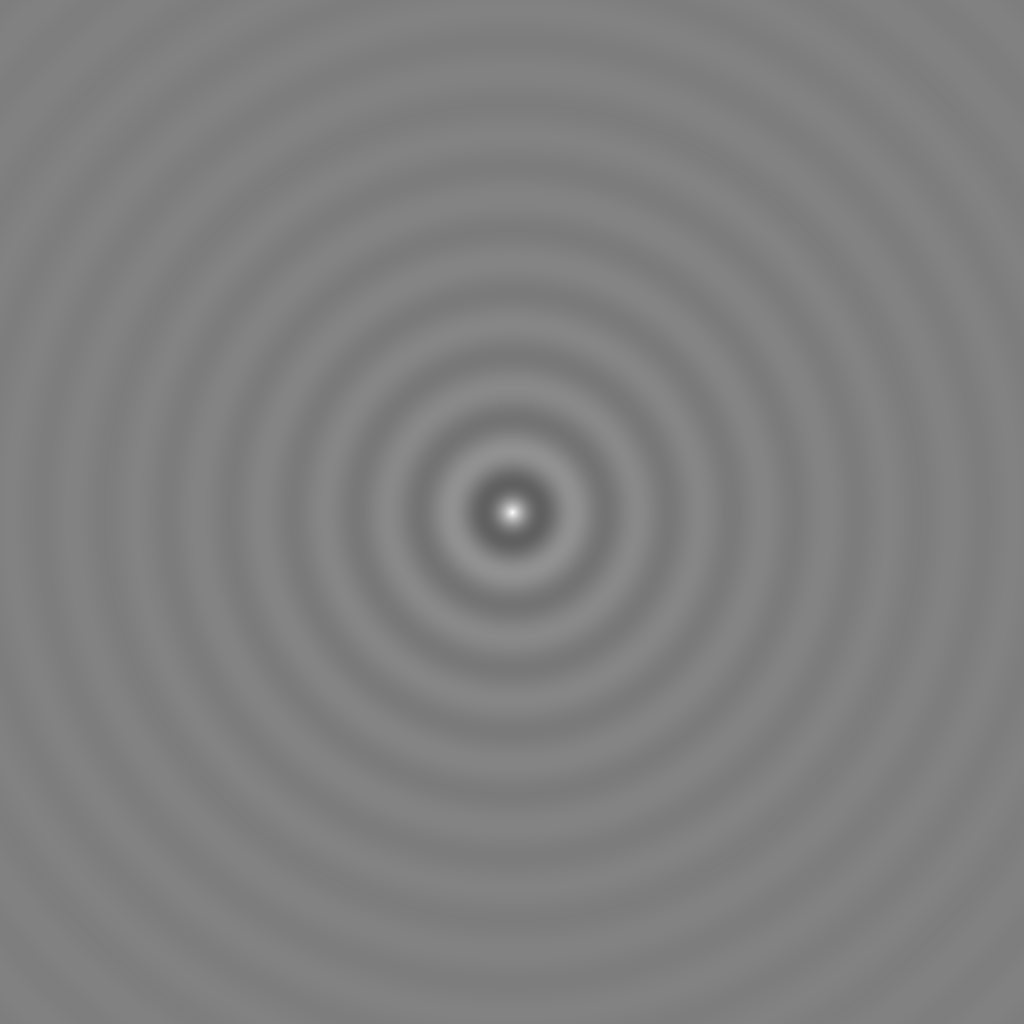

In [5]:
#include "headers/display.hpp"

im::image ripple_image("assets/ripple.png");
xcpp::display(ripple_image);